<a href="https://colab.research.google.com/github/pyafv/assets/blob/main/jupyter/calibration.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Install **pyafv** in Google Colab

In [ ]:
!pip install pyafv

In [2]:
import pyafv as afv
import pyafv.calibrate as cal

import matplotlib.pyplot as plt

We will use the default parameter set as an example for calibration.

In [3]:
phys = afv.PhysicalParams()
print(phys)

PhysicalParams(r=1.0, A0=3.141592653589793, P0=4.8, KA=1.0, KP=1.0, Lambda=0.2, delta=0.45)


#### ===============  Auto calibrate ==================

In [4]:
f_detach, phys_cal = cal.auto_calibrate(phys, show=True)

print(f"Detachment force from DP model: {f_detach:.1f}")
print(f"{phys_cal=}")

Calibrating:   0%|          | 0/100 [00:00<?, ?it/s]

Detachment force from DP model: 4.0
phys_cal=PhysicalParams(r=0.8703157319706735, A0=3.141592653589793, P0=4.8, KA=1.0, KP=1.0, Lambda=0.2, delta=0.16868881988698275)


### The following steps illustrate the automatic calibration described above

The `auto_calibrate` process above is equivalent to applying a series of external forces until detachment and computing the delta value of finite Voronoi model that matches the detachment force of DP model.

sim.detached=False


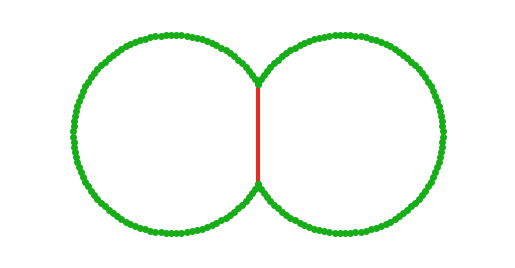

In [5]:
sim = cal.DeformablePolygonSimulator(phys)

# Initial shape
print(f"{sim.detached=}")
fig, ax = plt.subplots()
sim.plot_2d(ax)
plt.show()

#### ------------  Apply F = 2 -------------

sim.detached=False


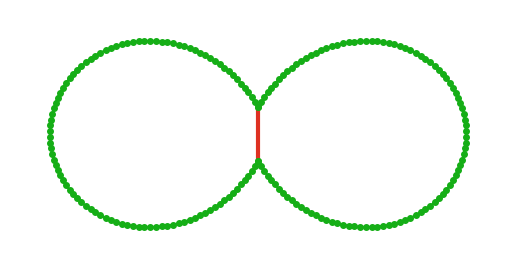

In [6]:
sim.simulate(ext_force=2.0, dt=1e-3, nsteps=50_000)
print(f"{sim.detached=}")

fig, ax = plt.subplots()
sim.plot_2d(ax)
plt.show()

#### ------------  Apply F = 4 -------------

sim.detached=True


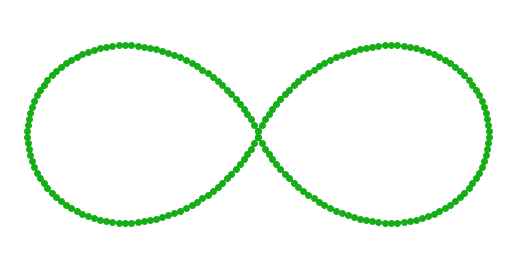

In [7]:
sim.simulate(ext_force=4.0, dt=1e-3, nsteps=50_000)
print(f"{sim.detached=}")

fig, ax = plt.subplots()
sim.plot_2d(ax)
plt.show()